In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)

### Задание 2. Значимость и доверительные интервалы ###

In [27]:
# Загрузка данных
file_path = 'ls_variants.xls'
df = pd.read_excel(file_path, sheet_name="вар. 6")

X = df.iloc[:, 0].values.reshape(-1, 1)
y = df.iloc[:, 1].values

X_min, X_max = np.min(X), np.max(X)
t = 2 * np.pi * (X - X_min) / (X_max - X_min)

In [28]:
def linear_regression_mnk(X, y):
    b = np.linalg.inv(X.T @ X) @ X.T @ y
    Y = X @ b
    e = y - Y
    S = e.T @ e
    n, s = X.shape
    sigma_squared = S / (n - s)
    return b, Y, e, S, sigma_squared, n, s

def fisher_test(n1, s1, n2, s2, X1, X2, S1, S2):
    s = s1 - s2
    F = ((S2 - S1) / s) / (S1 / (n1 - s1))
    q = stats.f.ppf(0.95, s, n1 - s1)
    return F < q

def student_test(n, s, X, sigma_squared, b):
    V = np.linalg.inv(X.T @ X)
    q = stats.t.ppf(0.75, n - s)
    t_values = np.abs(b / np.sqrt(sigma_squared * np.diag(V)))
    return t_values > q  # Булев массив значимости коэффициентов

def confidence_interval(X, sigma_squared, b, n, s, i):
    V = np.linalg.inv(X.T @ X)
    q = stats.t.ppf(0.95, n - s)
    return [b - q * np.sqrt(sigma_squared * V[i, i]), b + q * np.sqrt(sigma_squared * V[i, i])]

In [29]:
# Параметры модели
num_harmonics = 5  # Количество гармоник Фурье
poly_degree = 4  # Степень полинома

# Формирование XX1 (полином + ряд Фурье)
XX1 = np.column_stack([X**d for d in range(poly_degree + 1)] +
                      [np.cos(n * t) for n in range(1, num_harmonics + 1)] +
                      [np.sin(n * t) for n in range(1, num_harmonics + 1)])

In [30]:
# Построение первой модели
b1, Y1, e1, S1, sigma_squared1, n1, s1 = linear_regression_mnk(XX1, y)
R1 = r2_score(y, Y1)  
evr1 = np.var(e1, ddof=s1)  # Дисперсия остатков

# Формирование XX2 (только значимые факторы из XX1)
significant_factors = student_test(n1, s1, XX1, sigma_squared1, b1)
XX2 = XX1[:, [False,  True,  True,  True, True, True,  True, True, False,  True,  True,  True, True,  True,  True]]
print("Значимые коэффициенты в первой модели:", significant_factors)

Значимые коэффициенты в первой модели: [False  True  True  True False False  True False False  True  True  True
  True  True  True]


In [31]:
# Построение второй модели
b2, Y2, e2, S2, sigma_squared2, n2, s2 = linear_regression_mnk(XX2, y)
significant_factors2 = student_test(n2, s2, XX2, sigma_squared2, b2)
print("Значимые коэффициенты во второй модели:", significant_factors2)
R2 = r2_score(y, Y2)  
evr2 = np.var(e2, ddof=s2)

Значимые коэффициенты во второй модели: [ True  True  True  True  True  True  True  True  True  True  True  True
  True]


In [32]:
fisher_result = fisher_test(n1, s1, n2, s2, XX1, XX2, S1, S2)
print(fisher_result)

True


In [33]:
confidence_intervals = np.array([confidence_interval(XX2, sigma_squared2, b2[i], n2, s2, i) for i in range(len(b2))])

In [34]:
rows = []
for i, (coef, (low, high)) in enumerate(zip(b2, confidence_intervals)):
    interval_len = abs(high - low)
    decimals = max(0, -int(np.floor(np.log10(interval_len))) + 1) if interval_len != 0 else 2
    rounded_coef = round(coef, decimals)

    rows.append({
        "Изначальный коэффициент": coef,
        "Округлённый коэффициент": rounded_coef,
        "ДИ нижняя граница": low,
        "ДИ верхняя граница": high
    })

df_coefs = pd.DataFrame(rows)

# Настройка отображения и вывод
pd.set_option("display.float_format", "{:,.6f}".format)
print(df_coefs)

    Изначальный коэффициент  Округлённый коэффициент  ДИ нижняя граница  \
0                402.082669               402.000000         310.954743   
1             -2,872.912174            -2,873.000000      -3,257.373764   
2              4,870.128585             4,870.000000       4,417.581963   
3             -2,390.857609            -2,391.000000      -2,541.143039   
4                -41.287599               -41.300000         -43.777995   
5                 -4.245360                -4.250000          -4.386025   
6                 -0.163683                -0.164000          -0.205798   
7                  0.020858                 0.021000          -0.005956   
8                -10.893244               -11.000000         -16.438125   
9                 -8.105729                -8.100000          -8.777553   
10                -0.218586                -0.220000          -0.408750   
11                -0.033540                -0.030000          -0.111266   
12                -0.0338

In [35]:
q = stats.t.ppf(0.95, n2 - s2)
V = np.linalg.inv(XX2.T @ XX2)
conf_interval_pred = [Y2 - q * np.sqrt(sigma_squared2 * (XX2 @ V @ XX2.T).diagonal()),
                      Y2 + q * np.sqrt(sigma_squared2 * (XX2 @ V @ XX2.T).diagonal())]
conf_interval_resp = [Y2 - q * np.sqrt(sigma_squared2 * ((XX2 @ V @ XX2.T).diagonal() + 1)),
                      Y2 + q * np.sqrt(sigma_squared2 * ((XX2 @ V @ XX2.T).diagonal() + 1))]

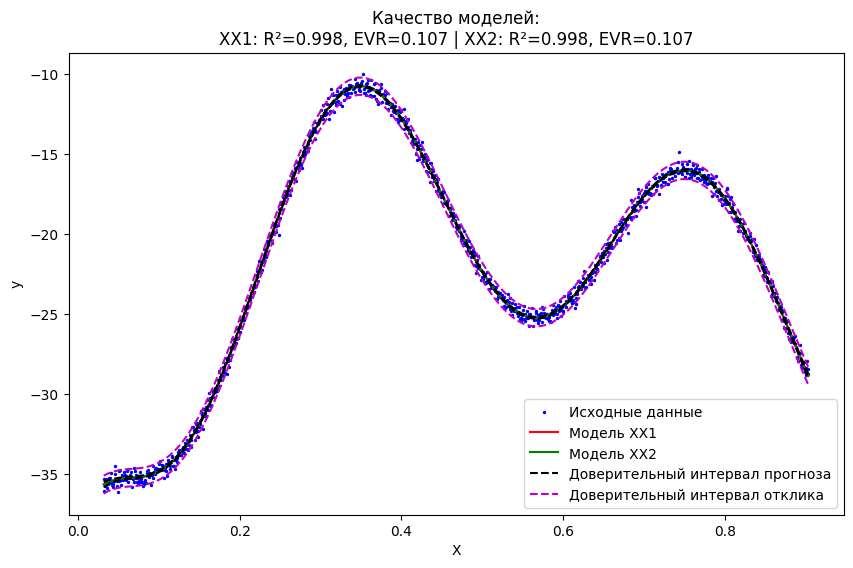

In [36]:
# Визуализация всех графиков на одном рисунке
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='b', label='Исходные данные', s=2)
plt.plot(X, Y1, 'r', label='Модель XX1')
plt.plot(X, Y2, 'g', label='Модель XX2')
plt.plot(X, conf_interval_pred[0], 'k--', label='Доверительный интервал прогноза')
plt.plot(X, conf_interval_pred[1], 'k--')
plt.plot(X, conf_interval_resp[0], 'm--', label='Доверительный интервал отклика')
plt.plot(X, conf_interval_resp[1], 'm--')
# Вывод R² и EVR в заголовке графика
plt.title(f"Качество моделей:\n"
          f"XX1: R²={R1:.3f}, EVR={evr1:.3f} | "
          f"XX2: R²={R2:.3f}, EVR={evr2:.3f}")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()